# Attribution EDA

## Setup

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import networkx as nx

In [2]:
# Load Data
df = pd.read_parquet("../data_storage/streamlit_app_data/final_dataset_with_attribution.parquet")

## Analysis

In [3]:
df.head()

,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,people_by_row,publication_name,...,vipr_score,vipr_weight,people_by_row_clean,headline_token_count,body_token_count,token_count,emotion_body,seq_index,circulation_size_bin,sentiment_score_bin
0,juliann ventura hill posted dec cst updated de...,18918986050,juliann_ventura,web,47759,opoint,warren rfk pick say goodbye smile say hello polio,2,"Elizabeth Warren, Juliann Ventura, Robert F Ke...",cw33,...,9872,617,"Elizabeth Warren, Juliann Ventura, Robert F Ke...",9,329,338,fear,1,4,5
1,geneva switzerland may ani health leaders coun...,18284984014,unknown,web,950,opoint,asia pacific countries sound alarm commit tack...,5,"Timor Leste, Vanuatu, Saia Piukala, Shiozaki A...",the_tennis_times,...,19500,1300,"Timor Leste, Vanuatu, Saia Piukala, Shiozaki A...",9,462,471,fear,2,1,5
2,providing top notch dental care new york city ...,18173606533,unknown,web,1094,opoint,tushin shah dds highly skilled dentist ascent ...,1,Tushin Shah,reporter_pass,...,38849,733,Tushin Shah,10,282,292,joy,3,2,5
3,navigating global health funding shift priorit...,19446163286,unknown,web,1048,opoint,wha daily update may,8,"Warren Buffett, Senait Fisseha, Tedros Ghebrey...",archynewsy,...,9350,550,"Warren Buffett, Senait Fisseha, Tedros Ghebrey...",4,1342,1346,fear,4,2,5
4,midday plans something matter spend antenna ho...,19119220222,unknown,broadcast,954,tveyes,wgn radio midday plans something matter spend ant,1,"Brian, Queen Anne, Samir Va, Mark Ruffalo, Lis...",wgn_am_radio,...,-1750,175,"Brian, Queen Anne, Samir Va, Mark Ruffalo, Lis...",8,377,385,joy,5,1,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45386 entries, 0 to 45385
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   article_body          45386 non-null  string                        
 1   article_id            45386 non-null  Int64                         
 2   author_name           45386 non-null  string                        
 3   channel_name          45386 non-null  string                        
 4   circulation_size      45386 non-null  Int32                         
 5   feed_name             45386 non-null  string                        
 6   headline              45386 non-null  string                        
 7   hit_strength          45386 non-null  Int16                         
 8   people_by_row         45386 non-null  string                        
 9   publication_name      45386 non-null  string                        
 10

In [5]:
df.describe(include='all')

,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,people_by_row,publication_name,...,vipr_score,vipr_weight,people_by_row_clean,headline_token_count,body_token_count,token_count,emotion_body,seq_index,circulation_size_bin,sentiment_score_bin
count,45386,45386.0,45386,45386,45386.0,45386,45386,45386.0,45386,45386,...,45386.0,45386.0,45386,45386.0,45386.0,45386.0,45386,45386.000000,45386.0,45386.0
unique,38176,<NA>,6881,4,<NA>,13,28023,<NA>,29308,7142,...,<NA>,<NA>,29308,<NA>,<NA>,<NA>,7,NaN,<NA>,<NA>
top,evidence living dead rats nest droppings found...,<NA>,unknown,web,<NA>,opoint,cbs news roundup,<NA>,Tedros Ghebreyesus,multidisciplinary_digital_publishing_institute,...,<NA>,<NA>,Tedros Ghebreyesus,<NA>,<NA>,<NA>,fear,NaN,<NA>,<NA>
freq,24,<NA>,31986,34145,<NA>,32173,213,<NA>,204,392,...,<NA>,<NA>,204,<NA>,<NA>,<NA>,19410,NaN,<NA>,<NA>
mean,NaN,18787051470.617218,NaN,NaN,2329277.132574,NaN,NaN,3.386705,NaN,NaN,...,-6030.490768,679.797118,NaN,8.549531,445.931653,454.481184,NaN,22096.340347,2.98808,3.018023
min,NaN,17813026449.0,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,...,-1080000.0,25.0,NaN,0.0,0.0,10.0,NaN,0.000000,1.0,1.0
25%,NaN,18341198017.75,NaN,NaN,1040.0,NaN,NaN,1.0,NaN,NaN,...,-12654.0,275.0,NaN,6.0,264.0,272.0,NaN,9471.250000,2.0,2.0
50%,NaN,18825339506.5,NaN,NaN,6557.0,NaN,NaN,2.0,NaN,NaN,...,-1950.0,502.0,NaN,8.0,376.0,384.0,NaN,21974.500000,3.0,3.0
75%,NaN,19235343718.5,NaN,NaN,153435.0,NaN,NaN,4.0,NaN,NaN,...,2906.25,950.0,NaN,10.0,493.0,502.0,NaN,34452.500000,4.0,4.0
max,NaN,19683932188.0,NaN,NaN,428640966.0,NaN,NaN,160.0,NaN,NaN,...,270000.0,20000.0,NaN,1129.0,3433.0,3446.0,NaN,46899.000000,5.0,5.0


In [6]:
def ensure_list(val):
    if isinstance(val, list):
        return val
    elif pd.isnull(val):
        return []
    else:
        # Assuming the delimiter is ', ' (comma and space)
        return [item.strip() for item in str(val).split(',') if item.strip()]

df['people_by_row_clean'] = df['people_by_row_clean'].apply(ensure_list)

df_exploded = df.explode('people_by_row_clean').rename(columns={'people_by_row_clean': 'person'})

In [7]:
df_exploded['published_datetime'] = pd.to_datetime(df_exploded['published_datetime'].astype(str), errors='coerce')

In [8]:
print(df_exploded['published_datetime'].dtype)

datetime64[ns, UTC]


In [9]:
df_exploded['month'] = df_exploded['published_datetime'].dt.to_period('M')

/var/folders/mt/qyhs8mhj6bd77bs78hd65s7w0000gn/T/ipykernel_79930/3488300392.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_exploded['month'] = df_exploded['published_datetime'].dt.to_period('M')


In [10]:
def to_clean_list(val):
    if isinstance(val, list):
        return val
    elif pd.isna(val):
        return []
    elif isinstance(val, str):
        # Adjust delimiter as needed, here ", " (comma + space)
        return [item.strip() for item in val.split(',') if item.strip()]
    else:
        return []

df['people_by_row_clean'] = df['people_by_row_clean'].apply(to_clean_list)

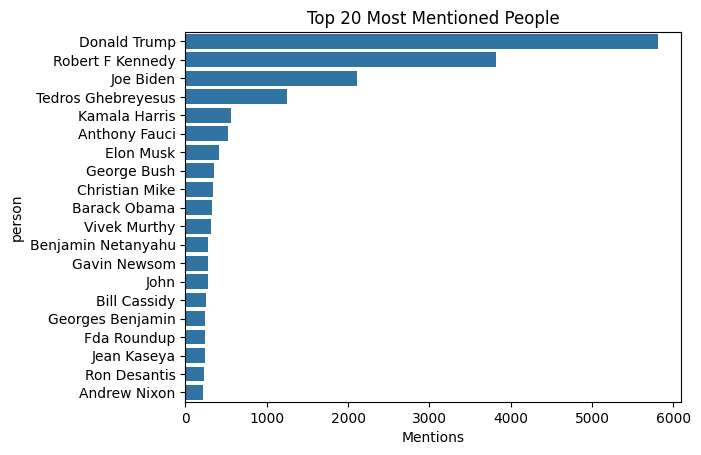

In [11]:
person_counts = df_exploded['person'].value_counts()
top_people = person_counts.head(20)
sns.barplot(x=top_people.values, y=top_people.index)
plt.title('Top 20 Most Mentioned People')
plt.xlabel('Mentions')
plt.show()

In [12]:
person_attribution = df_exploded.groupby('person').agg({
    'hit_strength': 'sum',
    'vipr_score': 'sum',
    'vipr_weight': 'sum',
    'sentiment_score': 'mean',
    'circulation_size': 'sum'
}).sort_values(by='vipr_score', ascending=False)

print(person_attribution.head(10))

                 hit_strength  vipr_score  vipr_weight  sentiment_score  \
person                                                                    
Oliver Guirdham           346     3321875       122568        26.535714   
Pm Modi                   394     1466349        87879        16.645161   
Julija Brett              203     1370109        54663        15.227273   
Graham Morrell            179      969127        49255        21.493333   
Rolf Sass                 180      957927        49955             21.0   
Hussain Rand              214      857685        30346             29.0   
Zsofia Kandrot             34      799123        25129             33.0   
Ayushman Bharat           255      786466        37098        23.193548   
Mahatma Gandhi            226      770641        40535        13.288889   
Robbie Robinson            26      753100         8181        91.666667   

                 circulation_size  
person                             
Oliver Guirdham           3

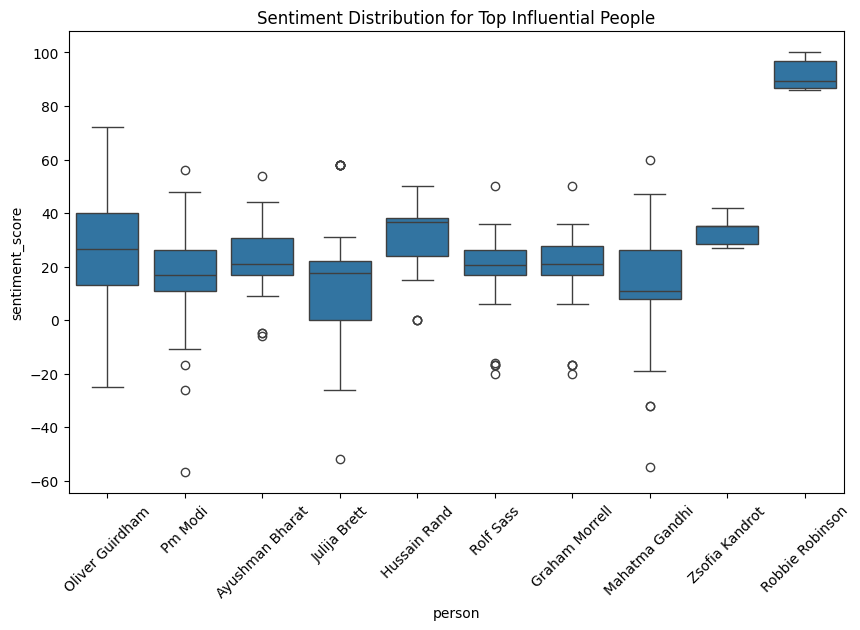

In [13]:
top_persons = person_attribution.head(10).index
subset = df_exploded[df_exploded['person'].isin(top_persons)]

plt.figure(figsize=(10,6))
sns.boxplot(data=subset, x='person', y='sentiment_score')
plt.title('Sentiment Distribution for Top Influential People')
plt.xticks(rotation=45)
plt.show()

In [14]:
df['published_datetime'] = pd.to_datetime(df['published_datetime'])

In [15]:
time_trends = df_exploded.groupby(['month', 'person'])['article_id'].count().reset_index()
top_time = time_trends[time_trends['person'].isin(top_persons)]

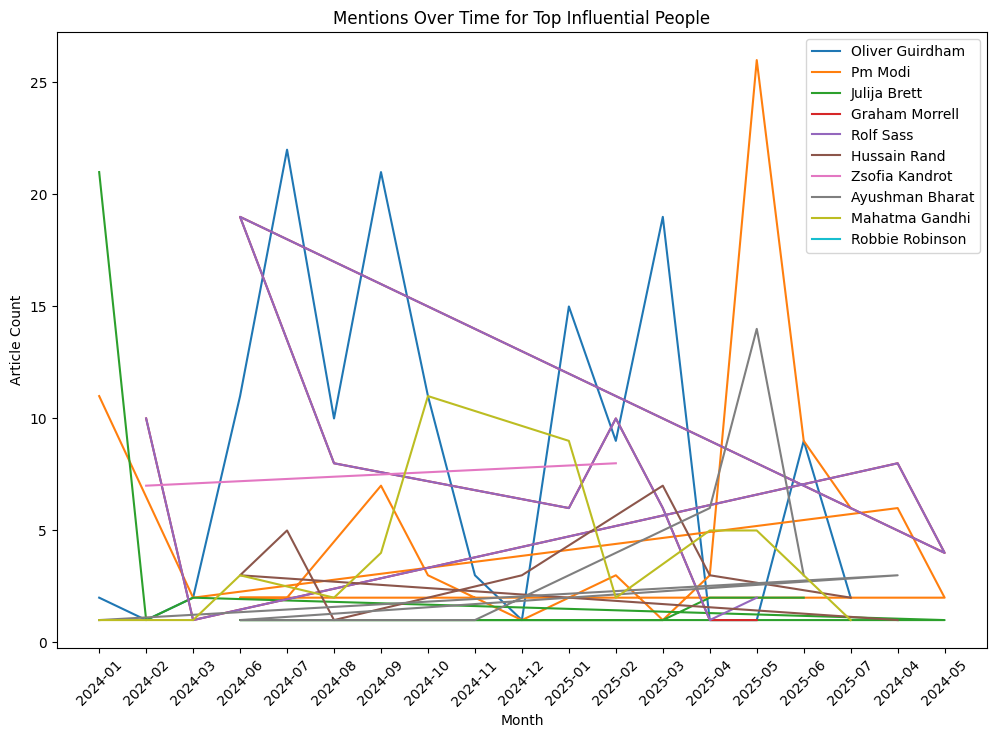

In [16]:
plt.figure(figsize=(12,8))
for person in top_persons:
    plt.plot(
        top_time[top_time['person']==person].month.astype(str),
        top_time[top_time['person']==person]['article_id'],
        label=person
    )
plt.legend()
plt.title('Mentions Over Time for Top Influential People')
plt.xlabel('Month')
plt.ylabel('Article Count')
plt.xticks(rotation=45)
plt.show()

In [17]:
person_circulation = df_exploded.groupby('person')['circulation_size'].sum().sort_values(ascending=False)
print("Top People by Estimated Audience Reach:\n", person_circulation.head(10))

Top People by Estimated Audience Reach:
 person
Donald Trump          7724185983
Robert F Kennedy      5954118048
Joe Biden             3637125505
Tedros Ghebreyesus    2041193377
Vivek Murthy          1546468286
Gavin Newsom          1287713392
L.                    1150865804
J.                    1112184312
Donald Trumps         1111215076
William Schaffner     1050418112
Name: circulation_size, dtype: Int64


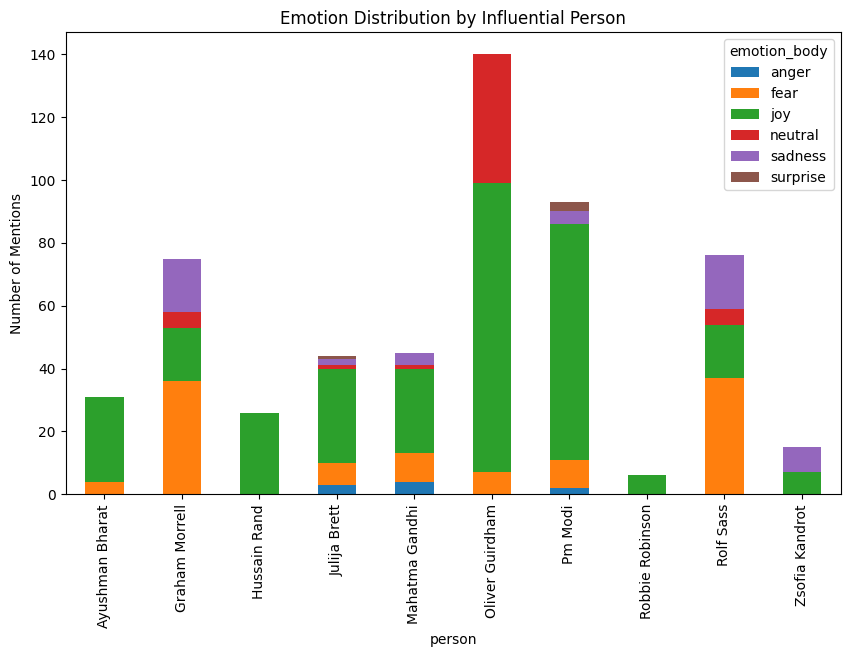

In [18]:
top_emotions = df_exploded[df_exploded['person'].isin(top_persons)].groupby(['person', 'emotion_body']).size().unstack(fill_value=0)
top_emotions.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Emotion Distribution by Influential Person')
plt.ylabel('Number of Mentions')
plt.show()

In [19]:
from itertools import combinations
from collections import Counter
person_pairs = df['people_by_row_clean'].dropna().apply(lambda x: list(combinations(x, 2)))
pair_counts = Counter([tuple(sorted(pair)) for sublist in person_pairs for pair in sublist])
print("Most common person pairs:", pair_counts.most_common(10))

Most common person pairs: [(('Donald Trump', 'Robert F Kennedy'), 2049), (('Donald Trump', 'Joe Biden'), 1225), (('Joe Biden', 'Robert F Kennedy'), 363), (('Donald Trump', 'Elon Musk'), 340), (('Donald Trump', 'Kamala Harris'), 324), (('Barack Obama', 'Donald Trump'), 234), (('Bill Cassidy', 'Robert F Kennedy'), 230), (('Donald Trump', 'Tedros Ghebreyesus'), 226), (('Anthony Fauci', 'Donald Trump'), 224), (('Donald Trump', 'George Bush'), 176)]


In [20]:
df_exploded['published_datetime'] = pd.to_datetime(df_exploded['published_datetime'].astype(str), errors='coerce')

In [21]:
top_people = (
    df_exploded['person']
    .value_counts()
    .head(20)
)
print("Top Contributors:\n", top_people)

Top Contributors:
 person
Donald Trump          5807
Robert F Kennedy      3817
Joe Biden             2110
Tedros Ghebreyesus    1254
Kamala Harris          564
Anthony Fauci          518
Elon Musk              414
George Bush            346
Christian Mike         334
Barack Obama           329
Vivek Murthy           312
Benjamin Netanyahu     283
Gavin Newsom           279
John                   273
Bill Cassidy           258
Georges Benjamin       245
Fda Roundup            238
Jean Kaseya            236
Ron Desantis           223
Andrew Nixon           217
Name: count, dtype: int64


In [22]:
total_mentions = df_exploded['person'].count()
share_of_voice = (top_people / total_mentions * 100)
print("Share of Voice (%):\n", share_of_voice)

Share of Voice (%):
 person
Donald Trump          2.504961
Robert F Kennedy      1.646536
Joe Biden             0.910189
Tedros Ghebreyesus    0.540937
Kamala Harris         0.243292
Anthony Fauci         0.223449
Elon Musk             0.178587
George Bush           0.149254
Christian Mike        0.144077
Barack Obama          0.141920
Vivek Murthy          0.134587
Benjamin Netanyahu    0.122077
Gavin Newsom          0.120352
John                  0.117764
Bill Cassidy          0.111293
Georges Benjamin      0.105685
Fda Roundup           0.102666
Jean Kaseya           0.101803
Ron Desantis          0.096195
Andrew Nixon          0.093607
Name: count, dtype: float64


In [23]:
first_seen = df_exploded.groupby('person')['published_datetime'].min()
last_seen = df_exploded.groupby('person')['published_datetime'].max()
period_range = last_seen - first_seen
print("Emerging Contributors (recent 30 days):\n",
      first_seen[first_seen > df_exploded['published_datetime'].max() - pd.Timedelta(days=30)])

Emerging Contributors (recent 30 days):
 person
A. Inverted-u      2025-07-09 14:27:00+00:00
Aaron Grisdale     2025-07-31 19:38:13+00:00
Aaron Mazetti      2025-07-10 21:36:44+00:00
Aaron Nosbisch     2025-07-23 09:03:26+00:00
Aaron Richterman   2025-07-27 04:10:14+00:00
                              ...           
Zooplankton        2025-07-24 08:20:02+00:00
Zubeda Hamid       2025-07-29 09:18:50+00:00
Zuliatu Cooper     2025-07-27 09:32:52+00:00
Zulkifli Ismail    2025-07-29 03:52:12+00:00
Zvokuomba          2025-08-01 06:18:37+00:00
Name: published_datetime, Length: 3040, dtype: datetime64[ns, UTC]


In [24]:
co_mention_df = (
    df[df['people_by_row_clean'].map(type) == list]['people_by_row_clean']
    .explode()
    .groupby(level=0)
    .apply(list)
)
pairs = (p for row in co_mention_df for p in combinations(sorted(set(row)), 2))
edge_counts = pd.Series(list(pairs)).value_counts()
edges = [(a, b, {'weight': w}) for (a, b), w in edge_counts.items() if w > 1]

In [25]:
def streak_lengths(dts):
    dts = sorted(pd.to_datetime(dts))
    if len(dts) < 2:
        return 0
    return max(np.diff(dts)).days

person_dates = df_exploded.groupby('person')['published_datetime'].apply(list)
person_streaks = person_dates.apply(streak_lengths)
print("Longest gaps between mentions per person:\n", person_streaks.sort_values(ascending=False).head(10))

Longest gaps between mentions per person:
 person
Jordan                    5843.0
Alberta                   2784.0
Beau Kilmer               2700.0
Lunch                     2656.0
Luciana Borio             2550.0
Alcoholics Anonymous      2521.0
Marijuana Legalization    2511.0
Ottawa Citizen             911.0
Andrew Duffy               863.0
David Pugliese             863.0
Name: published_datetime, dtype: float64
